1- Evolución: grafico de lineas. Quiere ver evolución de produccion semanal.
2 - Evolución: gráfico de lineas. QUiere detectar error de valor en un lapso de tiempo. Gráfico de lineas va a mostrar el salto en el periodo de tiempo.
3- Gráfico de barras: Comparación entre distintos grupos. Comparativa de valores de consumo eléctrico en cada turno.
4- Histograma: Evolución separada en bloques, muestra valor de cada bloque en secuencia para mostrar evoluciónen cierto periodo de tiempo.


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

df  = pd.read_csv("sensores.csv")

In [ ]:
df.head()


,temperatura,presion,consumo_kwh,produccion,eficiencia
0,79.0,98.5,174.9,145.7,83.7
1,73.9,93.3,144.1,125.6,85.9
2,80.2,108.0,178.8,151.8,85.2
3,87.2,116.4,199.4,159.2,81.5
4,73.1,95.0,158.5,133.2,84.2


In [12]:
df.dtypes

temperatura    float64
presion        float64
consumo_kwh    float64
produccion     float64
eficiencia     float64
dtype: object

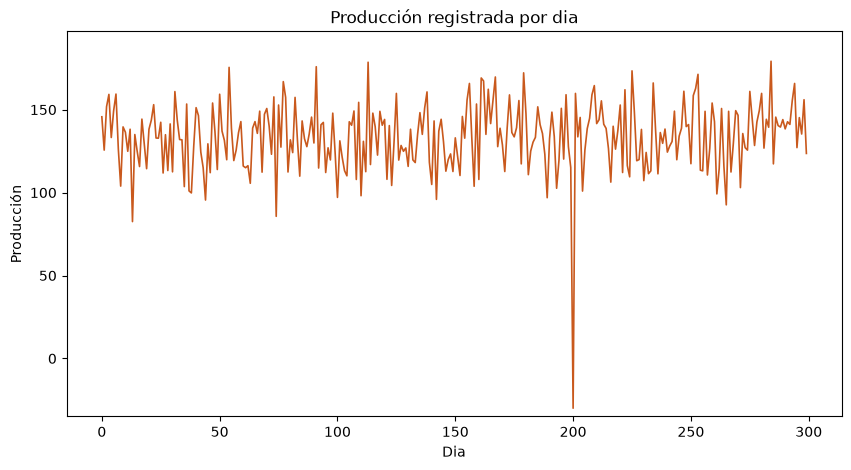

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df["produccion"], color="#c9591d", linewidth=1.2)
ax.set_title("Producción registrada por dia")
ax.set_xlabel("Dia")
ax.set_ylabel("Producción")
ax.set_ylim(-35, df["produccion"].max() * 1.1)
plt.show()

Tu jefe te escribe: "Necesito ver cómo viene la producción esta semana, envíame algo simple que pueda mirar en 5 segundos."

Crea un gráfico de líneas mostrando la producción a lo largo del dataset. Ponle título, nombre a los ejes, y asegúrate de que el eje Y no sea engañoso sobre el tamaño real de las variaciones.

Pistas:

Piensa si conviene que el eje Y comience en 0 o no, según lo que quieras comunicarle a tu jefe.
ax.set_xlabel(), ax.set_ylabel(), ax.set_title().

In [17]:
valor = df.loc[200, "produccion"]

print(valor)

-30.0


Un compañero de mantenimiento te dice: "Creo que un sensor de temperatura funcionó mal en algún momento, pero no sé cuándo. ¿Me puedes confirmar?"

Grafica la temperatura a lo largo de todo el dataset y comenta en qué zona aproximada del gráfico ves algo raro. No hace falta calcular nada — solo observar.

Pistas:

Un gráfico de líneas te muestra los saltos que no tienen continuidad con lo anterior ni con lo siguiente.
Si el salto es difícil de ver por la escala del eje Y, prueba ajustando set_ylim().

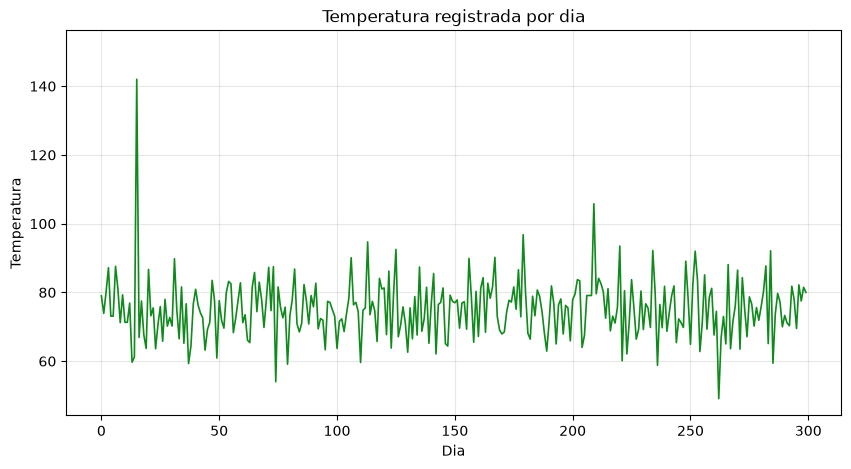

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df["temperatura"], color="#108a1c", linewidth=1.2)
ax.set_title("Temperatura registrada por dia")
ax.set_xlabel("Dia")
ax.set_ylabel("Temperatura")
ax.set_ylim(df["temperatura"].min() * 0.9, df["temperatura"].max() * 1.1)
ax.grid(alpha=0.3)
plt.show()

In [31]:
valor_temp = df.loc[15, "temperatura"]

print(valor_temp)

142.0


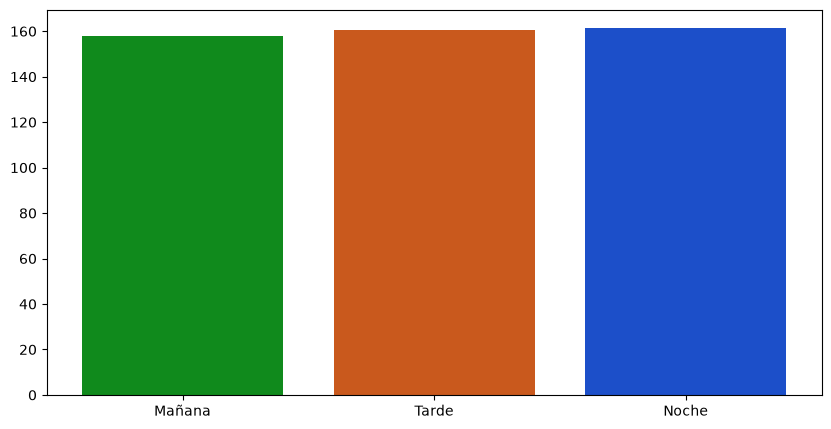

In [56]:
df_turno = df.copy()
df_turno["hora"] = df_turno.index % 24
df_turno["turnos"] = pd.cut(
    df_turno["hora"],
    bins=[0, 8, 16, 24],
    labels=["Mañana", "Tarde", "Noche"],
    right=False
)

consumo_agrupado = df_turno.groupby("turnos")["consumo_kwh"].mean()

fig,ax = plt.subplots(figsize=(10,5))
ax.bar(consumo_agrupado.index, consumo_agrupado.values, color=["#108a1c", "#c9591d", "#1c4fc9"])
plt.show()

Tu jefe ahora pregunta: "¿La segunda mitad del período que registramos consumió más o menos que la primera, turno por turno?"

Divide el dataset en dos mitades (usando el índice), calcula el consumo promedio por turno en cada mitad, y muéstralo con barras agrupadas (una al lado de la otra) para poder comparar turno por turno.

Pistas:

df.iloc[:150] y df.iloc[150:] para partir el dataset.
Repasa el ejemplo de barras agrupadas con x - ancho/2 y x + ancho/2 que vimos en una clase anterior de gráficos.

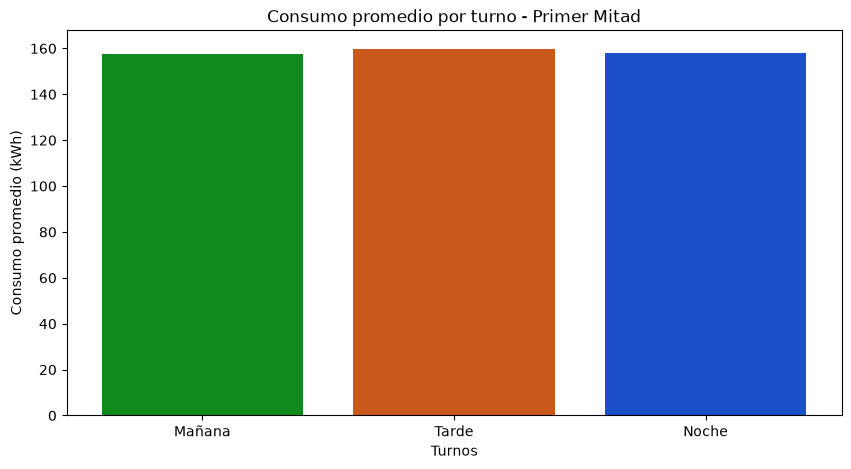

In [63]:
primer_mitad =df_turno.iloc[:150]
segunda_mitad = df_turno.iloc[150:]

primer_mitad_agrupado = primer_mitad.groupby("turnos")["consumo_kwh"].mean()
segunda_mitad_agrupado = segunda_mitad.groupby("turnos")["consumo_kwh"].mean()

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(primer_mitad_agrupado.index, primer_mitad_agrupado.values, color=["#108a1c", "#c9591d", "#1c4fc9"], label="Primer Mitad")
ax.set_title("Consumo promedio por turno - Primer Mitad")
ax.set_xlabel("Turnos")
ax.set_ylabel("Consumo promedio (kWh)")
plt.show()

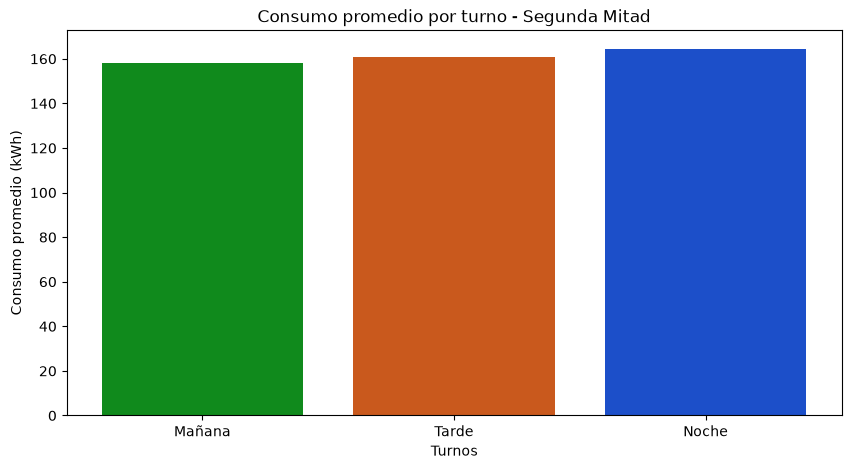

In [61]:
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(segunda_mitad_agrupado.index, segunda_mitad_agrupado.values, color=["#108a1c", "#c9591d", "#1c4fc9"], label="Segunda Mitad")
ax.set_title("Consumo promedio por turno - Segunda Mitad")
ax.set_xlabel("Turnos")
ax.set_ylabel("Consumo promedio (kWh)")
plt.show()

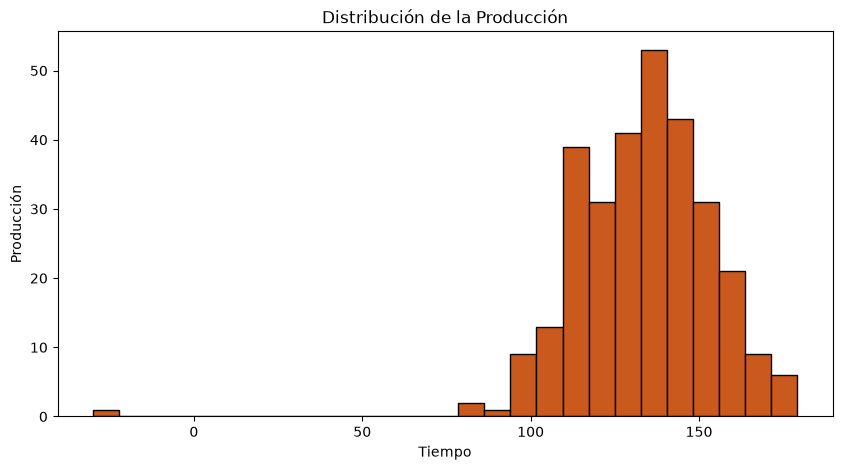

In [65]:
fig,ax = plt.subplots(figsize=(10,5))
ax.hist(df["produccion"], bins="fd", color="#c9591d", edgecolor="black")
ax.set_title("Distribución de la Producción")
ax.set_xlabel("Tiempo")
ax.set_ylabel("Producción")
plt.show()

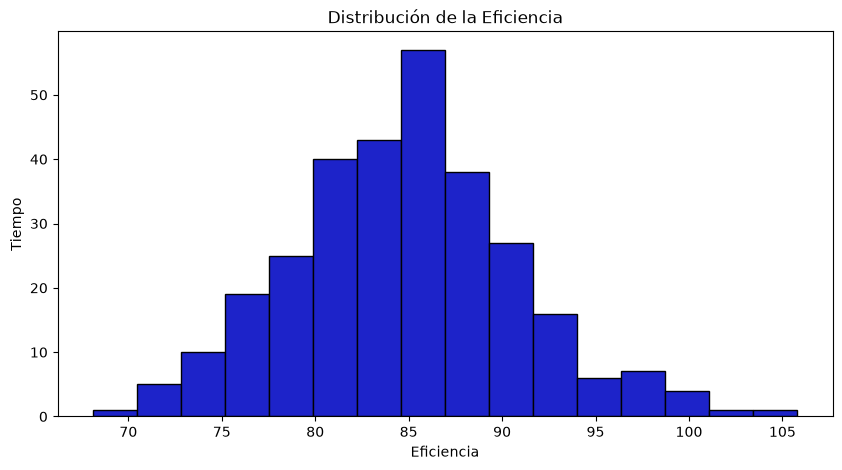

In [66]:
fig,ax = plt.subplots(figsize=(10,5))
ax.hist(df["eficiencia"], bins="fd", color="#1d23c9", edgecolor="black")
ax.set_title("Distribución de la Eficiencia")
ax.set_xlabel("Eficiencia")
ax.set_ylabel("Tiempo")
plt.show()

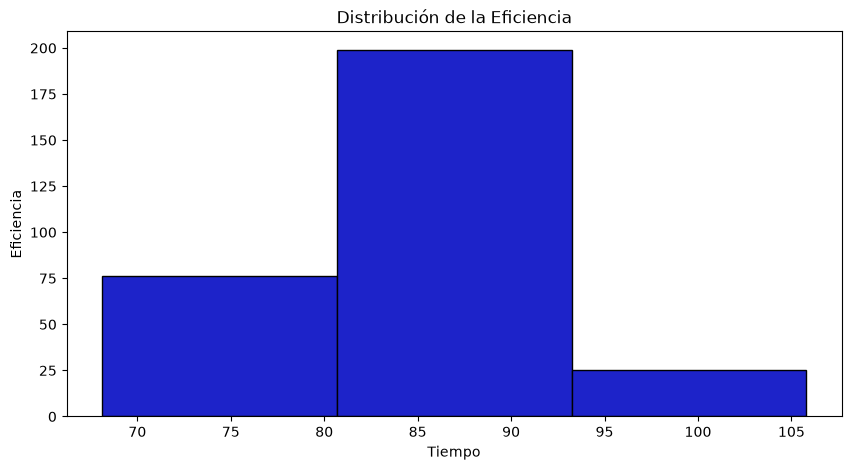

In [69]:
fig,ax = plt.subplots(figsize=(10,5))
ax.hist(df["eficiencia"], bins=3, color="#1d23c9", edgecolor="black")
ax.set_title("Distribución de la Eficiencia")
ax.set_xlabel("Tiempo")
ax.set_ylabel("Eficiencia")
plt.show()

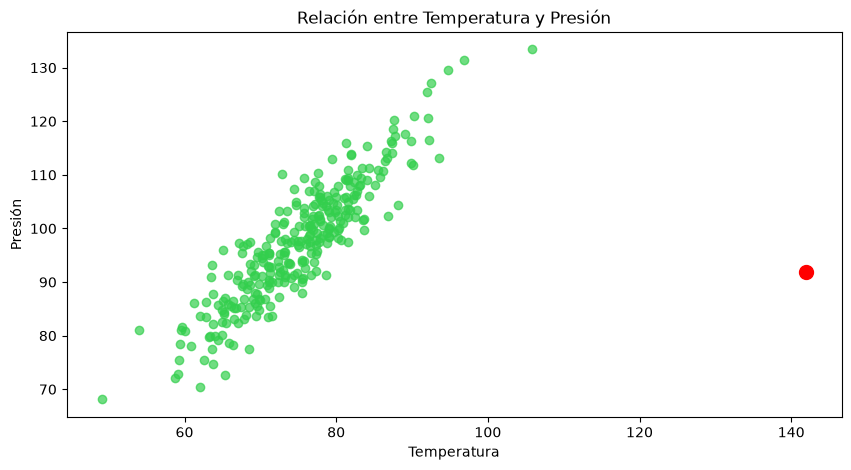

In [77]:
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(df["temperatura"], df["presion"], color="#33CF4D", alpha=0.7)
ax.set_title("Relación entre Temperatura y Presión")
ax.set_xlabel("Temperatura")
ax.set_ylabel("Presión")
ax.scatter(df.loc[15, "temperatura"], df.loc[15, "presion"], color="red", s=100, label="Sensor defectuoso")
plt.show()


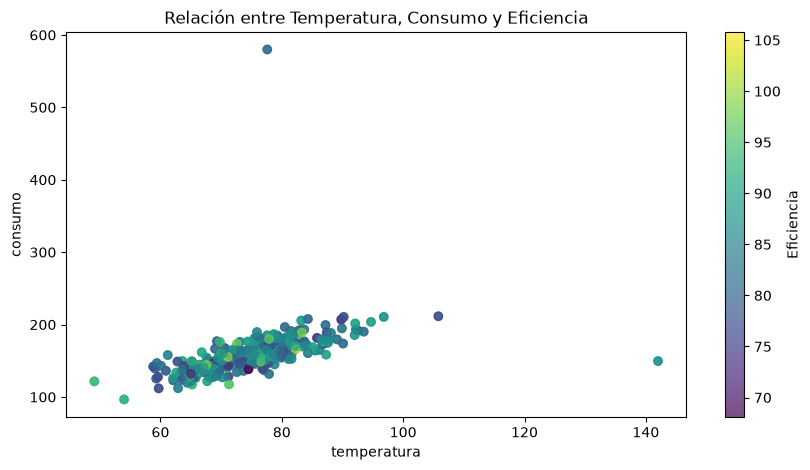

In [84]:
fig,ax = plt.subplots(figsize=(10, 5))
ax.scatter(df["temperatura"], df["consumo_kwh"], c= df["eficiencia"], cmap="viridis", alpha=0.7)
ax.set_title("Relación entre Temperatura, Consumo y Eficiencia")
ax.set_ylabel("consumo")
ax.set_xlabel("temperatura")

sc = ax.scatter(
    df["temperatura"],
    df["consumo_kwh"],
    c=df["eficiencia"],
    cmap="viridis",
    alpha=0.7
)

fig.colorbar(sc, ax=ax, label="Eficiencia")
plt.show()


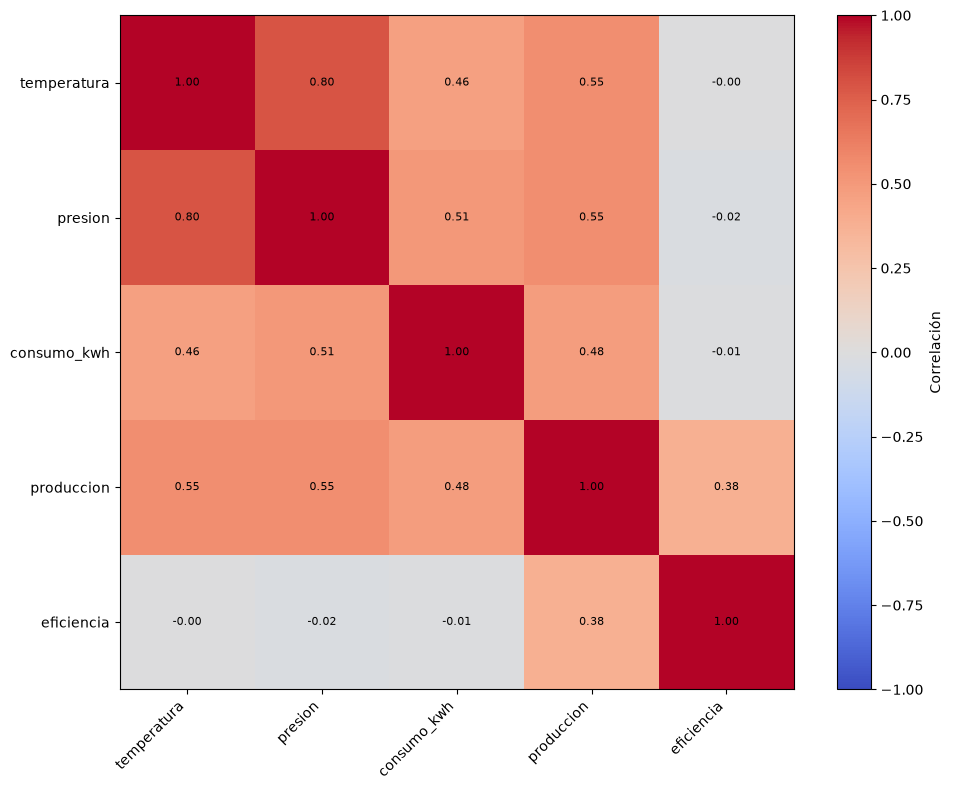

In [88]:
columnas = ["temperatura", "presion", "consumo_kwh", "produccion", "eficiencia"]
correlacion = df[columnas].corr()


fig,ax = plt.subplots(figsize=(10,8))
im = ax.imshow(correlacion, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(columnas)))
ax.set_yticks(range(len(columnas)))
ax.set_xticklabels(columnas, rotation=45, ha="right")
ax.set_yticklabels(columnas)
fig.colorbar(im, label="Correlación")

for i in range(len(columnas)):
    for j in range(len(columnas)):
        ax.text(j, i, f"{correlacion.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()